Set Up Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [23]:
df = pd.read_csv("online_food_sales_dataset.csv")
df.head()

,order_id,order_date,order_time,product_name,category,price,quantity,total_price,cost,profit,customer_id,customer_type,city,order_channel,payment_method,delivery_type,rating
0,ORD00001,2023-09-01,10:07:00,Chicken Wings,Appetizer,35000,1,35000,18000,17000,CUST0394,Returning,Semarang,Mobile App,Cash on Delivery,Standard,2
1,ORD00002,2023-07-04,13:22:00,Pizza Margherita,Main Course,85000,3,255000,135000,120000,CUST0053,Returning,Semarang,Website,E-Wallet,Standard,4
2,ORD00003,2023-10-25,16:02:00,Ice Cream Sundae,Dessert,25000,1,25000,10000,15000,CUST1359,Returning,Semarang,Mobile App,E-Wallet,Standard,3
3,ORD00004,2023-10-27,09:32:00,Iced Latte,Beverage,35000,4,140000,60000,80000,CUST0577,New,Jakarta,Mobile App,Cash on Delivery,Express,1
4,ORD00005,2023-04-02,19:17:00,Chocolate Brownie,Dessert,35000,1,35000,15000,20000,CUST0067,Returning,Semarang,Mobile App,Credit Card,Scheduled,4


Data Understanding

In [24]:
#Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        3000 non-null   object
 1   order_date      3000 non-null   object
 2   order_time      3000 non-null   object
 3   product_name    3000 non-null   object
 4   category        3000 non-null   object
 5   price           3000 non-null   int64 
 6   quantity        3000 non-null   int64 
 7   total_price     3000 non-null   int64 
 8   cost            3000 non-null   int64 
 9   profit          3000 non-null   int64 
 10  customer_id     3000 non-null   object
 11  customer_type   3000 non-null   object
 12  city            3000 non-null   object
 13  order_channel   3000 non-null   object
 14  payment_method  3000 non-null   object
 15  delivery_type   3000 non-null   object
 16  rating          3000 non-null   int64 
dtypes: int64(6), object(11)
memory usage: 398.6+ KB


In [25]:
#Basic Statistics
df.describe()

,price,quantity,total_price,cost,profit,rating
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,35030.000000,3.036333,106254.000000,54036.333333,52217.666667,2.980667
std,18784.924571,1.407246,79387.351645,42739.644816,37764.546975,1.420669
min,8000.000000,1.000000,8000.000000,3000.000000,5000.000000,1.000000
25%,25000.000000,2.000000,50000.000000,20000.000000,24000.000000,2.000000
50%,30000.000000,3.000000,90000.000000,45000.000000,45000.000000,3.000000
75%,35000.000000,4.000000,140000.000000,72000.000000,75000.000000,4.000000
max,85000.000000,5.000000,425000.000000,225000.000000,200000.000000,5.000000


In [26]:
#Missing Values Checking
df.isnull().sum()

,0
order_id,0
order_date,0
order_time,0
product_name,0
category,0
price,0
quantity,0
total_price,0
cost,0
profit,0


In [27]:
#Data Duplicate Checking
df.duplicated().sum()

np.int64(0)

Data Cleaning

In [28]:
#Date Convert
df['order_date'] = pd.to_datetime(df['order_date'])

In [29]:
#time Convert
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

Feature Engineering

In [30]:
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day_name()
df['hour'] = df['order_time'].dt.hour

Exploratory Data Analysis

In [31]:
#Total Revenue
df['total_price'].sum()

np.int64(318762000)

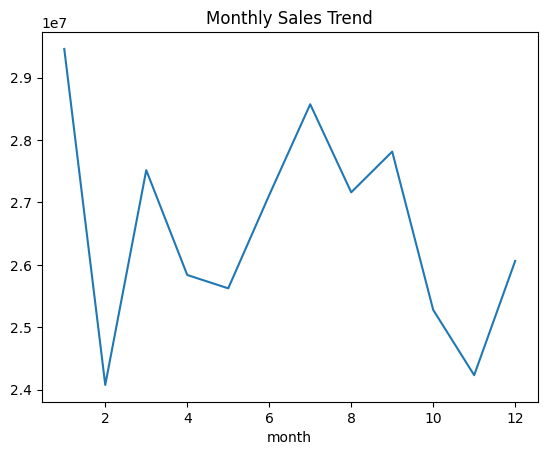

In [32]:
#Monthly Sales Trends
monthly_sales = df.groupby('month')['total_price'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

In [33]:
#Best Selling Products
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False)

top_products.head(10)

,quantity
product_name,
Boba Milk Tea,849
Iced Latte,801
Ayam Penyet,789
Pizza Margherita,784
Chocolate Brownie,773
Mineral Water,769
Beef Burger,764
Mie Ayam Jamur,740
Ice Cream Sundae,732


In [35]:
#Profit per Product
profit_product = df.groupby('product_name')['profit'].sum().sort_values(ascending=False)

profit_product.head(10)

,profit
product_name,
Pizza Margherita,31360000
Beef Burger,19100000
Iced Latte,16020000
Chocolate Brownie,15460000
Boba Milk Tea,13584000
Chicken Wings,12206000
Ice Cream Sundae,10980000
Nasi Goreng Spesial,9990000
Ayam Penyet,9468000


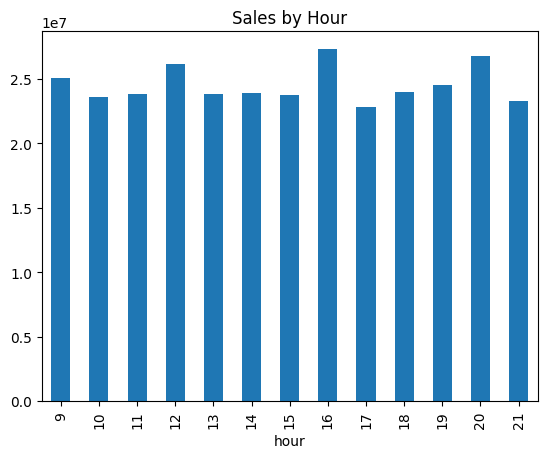

In [36]:
#Busiest Hours
hourly_sales = df.groupby('hour')['total_price'].sum()

hourly_sales.plot(kind='bar')
plt.title("Sales by Hour")
plt.show()

In [38]:
#Customer Behavior
df['customer_type'].value_counts()

,count
customer_type,
New,1506
Returning,1494


In [39]:
#Best Channel
df.groupby('order_channel')['total_price'].sum()

,total_price
order_channel,
Mobile App,106019000
Third-Party App,108348000
Website,104395000


**#Sales Trends insights & Recomendation**

---


**Insight**

Sales fluctuated throughout the year, with a significant decline in February, followed by an increase and peaking mid-year (around July). Afterward, sales declined again toward the end of the year before recovering slightly in December.

**Recomendation**

Focus promotional strategies and stock increases in the mid-year period to maximize sales, as well as designing special campaigns at the beginning of the year to address declining demand.

**#Best Selling Products insights & Recomendation**

---


**Insight**

Beverages like boba milk tea and iced latte dominated sales as top-selling items, followed by main dishes like smashed chicken and Margherita pizza. This indicates that beverages are in high demand and play a key role in driving sales, while food remains a key complement to sales.

**Recomendation**

Based on the analysis, the business should prioritize its beverage products as the core offering, as they contribute the highest sales volume and act as a primary driver for customer purchases. To maximize revenue, it is recommended to implement bundling strategies by combining best-selling drinks such as Boba Milk Tea and Iced Latte with food items, thereby increasing the average transaction value. Additionally, ensuring consistent stock availability for top-performing products is essential to avoid lost sales opportunities. The business can also leverage these popular items in marketing campaigns and apply upselling strategies, such as offering add-ons or combo deals, to further enhance customer spending and overall profitability.